# Predicted Traffic Volume (AADT) Projection

In [13]:
import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.ops import linemerge

# Project paths
DATA_DIR = Path('../Data/Raw')
CLEANED_DIR = Path('../Data/Cleaned')
OUTPUT_DIR = Path('../Data/Cleaned')

CRS_BNG = 'EPSG:27700'

pd.set_option('display.max_columns', None)
print(f"Working directory: {os.getcwd()}")


Working directory: /Users/pippin/Library/CloudStorage/OneDrive2-UniversityCollegeLondon/Dissertation_CASA&TfWM/Code


## 1. Load Input Data

This notebook assigns traffic volume (AADT) to the cycleable network for the LTN 1/20
Figure 4.1 adequacy assessment, which requires both **speed** and **traffic volume** as inputs.

### Input Datasets

| File | Source | Description |
|---|---|---|
| `cycleable_directed_network.parquet` | `00_data_processing` output | Unified cycleable network with 8-category facility type classification |
| `wm_minor_road_predicted_aadt.gpkg` | Volume estimation output | Predicted AADT for **minor roads** (residential, tertiary, unclassified, secondary) via the Morley & Gulliver (2016) pgRouting/Poisson GLM approach |
| `dft_traffic_counts_aadf.csv` | [DfT Road Traffic Statistics](https://roadtraffic.dft.gov.uk/downloads)https://roadtraffic.dft.gov.uk/downloads) | Official AADF count point data, used here for **A Roads** which are not covered by the minor road prediction model |

### AADT Assignment Strategy

AADT is projected to all links in the cycleable network. The two AADT sources serve
complementary roles, determined by road classification

| Road Classification | AADT Source | Rationale |
|---|---|---|
| **A Road** | DfT AADF count points (linear referencing) | The prediction model uses `nearest_major_aadt` as an input feature, creating a circular dependency if applied to major roads. DfT AADF is the official UK source for major road traffic volumes. |
| **B Road, Classified Unnumbered, Not Classified, Unclassified** | Predicted AADT (Morley & Gulliver model) | DfT count points are sparsely distributed on minor roads. The routing-based prediction model provides continuous coverage. |
| **Remaining gaps** | Road classification median | Predominantly residential streets with `Unknown` classification where OSM coverage is incomplete. Filled using the median AADT of matched links within the same `roadclassification` group. |

Off-carriageway links (shared use paths, fully kerbed cycle tracks) will naturally receive
low or no matched AADT; the downstream LTS classification determines which links actually
use the volume value.

In [14]:
# =============================================================================
# 1. Load input data
# =============================================================================

# --- 1a. Cycleable network ---
network = gpd.read_parquet(CLEANED_DIR / "cycleable_directed_network.parquet")

# --- 1b. Predicted AADT (minor roads) ---
aadt = gpd.read_file(CLEANED_DIR / "wm_minor_road_predicted_aadt.gpkg")
if aadt.crs != CRS_BNG:
    aadt = aadt.to_crs(CRS_BNG)
print(f"\nPredicted AADT (minor roads): {aadt.shape[0]:,} links")
print(f"  OSM road classes: {', '.join(aadt['fclass'].unique())}")
print(f"  AADT range: {aadt['predicted_aadt'].min():.0f} – {aadt['predicted_aadt'].max():.0f}")

# --- 1c. DfT AADF count points ---
dft_aadf = pd.read_csv(
    DATA_DIR / "DfT_Road_Traffic_Statistics/dft_traffic_counts_aadf/dft_traffic_counts_aadf.csv"
)
latest_year = dft_aadf['year'].max()
dft_aadf = dft_aadf[dft_aadf['year'] == latest_year].copy()
dft_aadf = gpd.GeoDataFrame(
    dft_aadf,
    geometry=gpd.points_from_xy(dft_aadf['easting'], dft_aadf['northing']),
    crs=CRS_BNG
)
dft_aadf = dft_aadf[['count_point_id', 'road_name', 'road_type',
                      'all_motor_vehicles', 'geometry']].rename(
    columns={'all_motor_vehicles': 'dft_aadt'}
)
print(f"\nDfT AADF: {dft_aadf.shape[0]:,} count points (year={latest_year})")

# --- 1d. Study area boundary ---
STUDY_AREA_BOROUGHS = [
    'Birmingham', 'Coventry', 'Dudley', 'Sandwell',
    'Solihull', 'Walsall', 'Wolverhampton',
]
raw_data = gpd.read_file(
    DATA_DIR / "Local_Authority_Districts_DEC_2025_Boundaries_UK_BFC_7781342770234899863/LAD_DEC_2025_UK_BFC.shp"
)
study_area = raw_data[raw_data['LAD25NM'].isin(STUDY_AREA_BOROUGHS)].to_crs(CRS_BNG)
study_area_union = study_area.unary_union
dft_wm = dft_aadf[dft_aadf.within(study_area_union)].copy()
print(f"DfT count points in study area: {dft_wm.shape[0]:,}")



Predicted AADT (minor roads): 99,833 links
  OSM road classes: tertiary, unclassified, residential, secondary
  AADT range: 338 – 18046

DfT AADF: 22,337 count points (year=2024)
DfT count points in study area: 656


## 2. Join Traffic Volume to Cycleable Network

### 2.1 Minor Roads — Predicted AADT

The predicted AADT model (Morley & Gulliver, 2016) outputs AADT estimates on an OSM-derived
road network covering four road classes - `residential`, `tertiary`, `unclassified`, and
`secondary`. These are joined to the OS NGD cycleable network via **spatial nearest-neighbour
matching** (centroid-to-nearest-line, 30m threshold).

The 30m threshold accounts for minor geometric discrepancies between the OSM and OS NGD
networks while avoiding cross-contamination from adjacent roads. Predicted AADT is assigned
only to **non-A Road** links; A Roads are handled separately in Section 2.2.

In [15]:
# =============================================================================
# 2.1 Minor Roads — Predicted AADT (spatial nearest-neighbour)
# =============================================================================

centroids = network.copy()
centroids['_centroid'] = centroids.geometry.centroid
centroids = centroids.set_geometry('_centroid')

joined_minor = gpd.sjoin_nearest(
    centroids[['osid', '_centroid']],
    aadt[['geometry', 'predicted_aadt']],
    how='left',
    max_distance=30,
    distance_col='minor_match_dist'
).sort_values('minor_match_dist').drop_duplicates('osid', keep='first')

# Merge to network
network = network.merge(
    joined_minor[['osid', 'predicted_aadt', 'minor_match_dist']],
    on='osid', how='left'
)

# Assign predicted AADT to non-A Roads only
non_a_mask = network['roadclassification'] != 'A Road'
network.loc[non_a_mask & network['predicted_aadt'].notna(), 'aadt'] = (
    network.loc[non_a_mask & network['predicted_aadt'].notna(), 'predicted_aadt']
)
network.loc[non_a_mask & network['predicted_aadt'].notna(), 'aadt_source'] = 'predicted'

# Summary
print("Minor roads (non-A Road) AADT coverage:")
print(f"  Matched:   {network.loc[non_a_mask, 'aadt'].notna().sum():,}")
print(f"  Unmatched: {network.loc[non_a_mask, 'aadt'].isna().sum():,}")

Minor roads (non-A Road) AADT coverage:
  Matched:   382,409
  Unmatched: 71,986


### 2.2 A Roads — DfT AADF Count Points

A Roads are not covered by the minor road prediction model, which uses `nearest_major_aadt`
as an input feature (Morley & Gulliver, 2016), creating a circular dependency if applied to
major roads. Instead, AADT is obtained from the DfT Annual Average Daily Flow (AADF) count
point data — the official UK source for major road traffic volumes.

#### DfT Link-Level Data Structure

The DfT major road network is divided into **links**, defined as continuous road sections
between major junctions. Each link has a uniquely referenced **Count Point (CP)** where
traffic is counted or estimated
([DfT, Road Traffic Estimates Methodology Note](https://assets.publishing.service.gov.uk/media/63332990e90e0711d82ae0ed/annual-methodology-note.pdf)).https://assets.publishing.service.gov.uk/media/63332990e90e0711d82ae0ed/annual-methodology-note.pdf)).
The DfT provides AADF estimates for every link on the motorway and A-road network, derived
from manual traffic counts expanded to annual averages using Automatic Traffic Counter (ATC)
data. Where a count has not been conducted in the current year, the AADF is estimated from
the previous year's value using regional growth factors.

It should be noted that DfT's traffic estimates at the individual road link level are less
robust than regional or national aggregates, as they are not always based on up-to-date
counts at each location
([DfT, Data Disclaimer](https://roadtraffic.dft.gov.uk/about)).https://roadtraffic.dft.gov.uk/about)).

#### Assignment Method

Since the OS NGD road network is segmented at a finer granularity than the DfT link network
(multiple OS NGD links fall within a single DfT link), a **linear referencing** approach
is used to assign DfT AADT to each OS NGD A Road link

1. For each road number (e.g. A38), all OS NGD links are merged into a continuous
   centreline using `shapely.ops.linemerge`.
2. All DfT count points on the same road number (nationally, not clipped to the study area,
   to ensure boundary roads are covered) are projected onto this centreline, producing a
   1D position for each count point.
3. Each OS NGD link's centroid is similarly projected onto the centreline.
4. Each OS NGD link is assigned the AADT of the **nearest count point along the road**
   (by 1D distance), ensuring that the assignment follows the road's geometry rather
   than Euclidean proximity, which could cross-contaminate between parallel roads.

This method respects the DfT's own link-level data structure - OS NGD segments within the
same DfT link (i.e. between the same pair of major junctions) receive the same AADT value.

For one road (A4545, 41 links) where no DfT count point exists, AADT was assigned from the
nearest matched A Road link by spatial proximity.

In [16]:
# =============================================================================
# 2.2 A Roads — DfT AADT via linear referencing along each road
# =============================================================================

# --- Step 1: Prepare data ---
a_mask = network['roadclassification'] == 'A Road'
a_links = network[a_mask].copy()
a_links['road_num'] = a_links['roadclassificationnumber'].str.strip().str.upper()
dft_aadf['road_num'] = dft_aadf['road_name'].str.strip().str.upper()

# --- Step 2: For each road number, match via 1D linear referencing ---
results = []

for road_num in a_links['road_num'].dropna().unique():
    links_r = a_links[a_links['road_num'] == road_num]
    cps_r = dft_aadf[dft_aadf['road_num'] == road_num]
    
    if len(cps_r) == 0:
        continue
    
    # Merge OS links into continuous line(s)
    merged = linemerge(links_r.geometry.unary_union)
    
    # Project count points onto merged line → 1D positions
    cp_positions = []
    for _, cp in cps_r.iterrows():
        dist_along = merged.project(cp.geometry)
        cp_positions.append({
            'dist_along': dist_along,
            'dft_aadt': cp['dft_aadt'],
        })
    cp_df = pd.DataFrame(cp_positions).sort_values('dist_along')
    
    # For each OS NGD link, project centroid → find nearest CP in 1D
    for _, link in links_r.iterrows():
        centroid = link.geometry.centroid
        link_pos = merged.project(centroid)
        cp_df['dist_1d'] = (cp_df['dist_along'] - link_pos).abs()
        nearest = cp_df.loc[cp_df['dist_1d'].idxmin()]
        results.append({
            'osid': link['osid'],
            'dft_aadt': nearest['dft_aadt'],
            'match_dist_1d': nearest['dist_1d']
        })

result_df = pd.DataFrame(results)
result_df = result_df.drop_duplicates('osid', keep='first')

# --- Step 3: Merge matched results back to network ---
network = network.merge(
    result_df[['osid', 'dft_aadt']].rename(columns={'dft_aadt': 'a_road_aadt'}),
    on='osid', how='left'
)
has_a = network['a_road_aadt'].notna()
network.loc[has_a, 'aadt'] = network.loc[has_a, 'a_road_aadt']
network.loc[has_a, 'aadt_source'] = 'dft'
network.drop(columns='a_road_aadt', inplace=True)

# --- Step 4: Fill remaining A Roads (no DfT count point for that road number) ---
still_missing = (network['roadclassification'] == 'A Road') & (network['aadt'].isna())
if still_missing.sum() > 0:
    a_matched = network[
        (network['roadclassification'] == 'A Road') & (network['aadt'].notna())
    ]
    missing_links = network[still_missing].copy()
    missing_links['_centroid'] = missing_links.geometry.centroid
    
    filled = gpd.sjoin_nearest(
        missing_links.set_geometry('_centroid')[['osid', '_centroid']],
        a_matched[['geometry', 'aadt']].rename(columns={'aadt': 'fill_aadt'}),
        how='left',
        distance_col='fill_dist'
    ).drop_duplicates('osid', keep='first')
    
    network = network.merge(filled[['osid', 'fill_aadt']], on='osid', how='left')
    has_fill = network['fill_aadt'].notna()
    network.loc[has_fill, 'aadt'] = network.loc[has_fill, 'fill_aadt']
    network.loc[has_fill, 'aadt_source'] = 'nearest_a_road'
    network.drop(columns='fill_aadt', inplace=True)

# --- Summary ---
a_final = network[network['roadclassification'] == 'A Road']
print("=" * 60)
print("A ROAD AADT ASSIGNMENT")
print("=" * 60)
print(f"Total A Road links: {a_final.shape[0]:,}")
print(f"  Matched (linear ref): {result_df.shape[0]:,}")
print(f"  Filled (nearest):     {still_missing.sum():,}")
print(f"  Coverage:             {a_final['aadt'].notna().sum():,} / {a_final.shape[0]:,}")
print(f"\n1D match distance (linear referencing):")
print(result_df['match_dist_1d'].describe())
print(f"\nMedian AADT: {a_final['aadt'].median():.0f}")

A ROAD AADT ASSIGNMENT
Total A Road links: 25,833
  Matched (linear ref): 19,395
  Filled (nearest):     41
  Coverage:             25,833 / 25,833

1D match distance (linear referencing):
count    19395.000000
mean       875.496954
std        906.440550
min          0.102739
25%        257.042856
50%        583.756960
75%       1176.360493
max       7349.386954
Name: match_dist_1d, dtype: float64

Median AADT: 17927


### 2.3 Remaining Gaps — Road Classification Median

For links still missing AADT after Steps 2.1 and 2.2, default values are assigned
using the **median AADT of matched links within the same `roadclassification` group**.

These are predominantly residential streets with `Unknown` or `Not Classified` road
classification where the OSM-derived prediction network has incomplete coverage. Given their
route hierarchy (mostly `Restricted Local Access Road` and `Restricted Secondary Access Road`),
these are low-traffic roads where the exact AADT value has minimal impact on the LTS
classification — at 30 mph, even 500 AADT already triggers a Cycle Lane recommendation
under Figure 4.1.

Median is preferred over mean because AADT distributions are right-skewed (a small number of
high-traffic links inflate the mean).

In [17]:
# =============================================================================
# 2.3 Remaining Gaps — Road Classification Median
# =============================================================================

# Compute median AADT by road classification from matched data
matched = network[network['aadt'].notna()]
class_median = matched.groupby('roadclassification')['aadt'].agg(['median', 'mean', 'count'])
print("AADT by road classification (from matched data):")
print(class_median.sort_values('median', ascending=False))

# Fill gaps
missing_mask = network['aadt'].isna()
print(f"\nFilling {missing_mask.sum():,} links by road classification median")

network.loc[missing_mask, 'aadt'] = (
    network.loc[missing_mask, 'roadclassification'].map(
        class_median['median'].to_dict()
    )
)
network.loc[
    missing_mask & network['aadt'].notna(), 'aadt_source'
] = 'class_median'

# Final coverage check
still_missing = network['aadt'].isna()
print(f"Still missing after all steps: {still_missing.sum():,}")

# Final summary
print(f"\nAADT source distribution:")
print(network['aadt_source'].value_counts(dropna=False))

AADT by road classification (from matched data):
                             median          mean   count
roadclassification                                       
A Road                 17927.000000  20639.572640   25833
B Road                 10074.975013   9867.710983   16800
Classified Unnumbered   5819.939876   5434.486856   17526
Unknown                 1427.245845   2299.003480   36360
Unclassified            1397.795595   1980.591896  239107
Not Classified          1349.257225   1575.033862   18782

Filling 71,986 links by road classification median
Still missing after all steps: 36,212

AADT source distribution:
aadt_source
predicted         382409
NaN                36212
class_median       35774
dft                25792
nearest_a_road        41
Name: count, dtype: int64


## 3. AADT Assignment Validation

### 3.1 AADT Source Map

Spatial distribution of AADT data sources across the cycleable network.

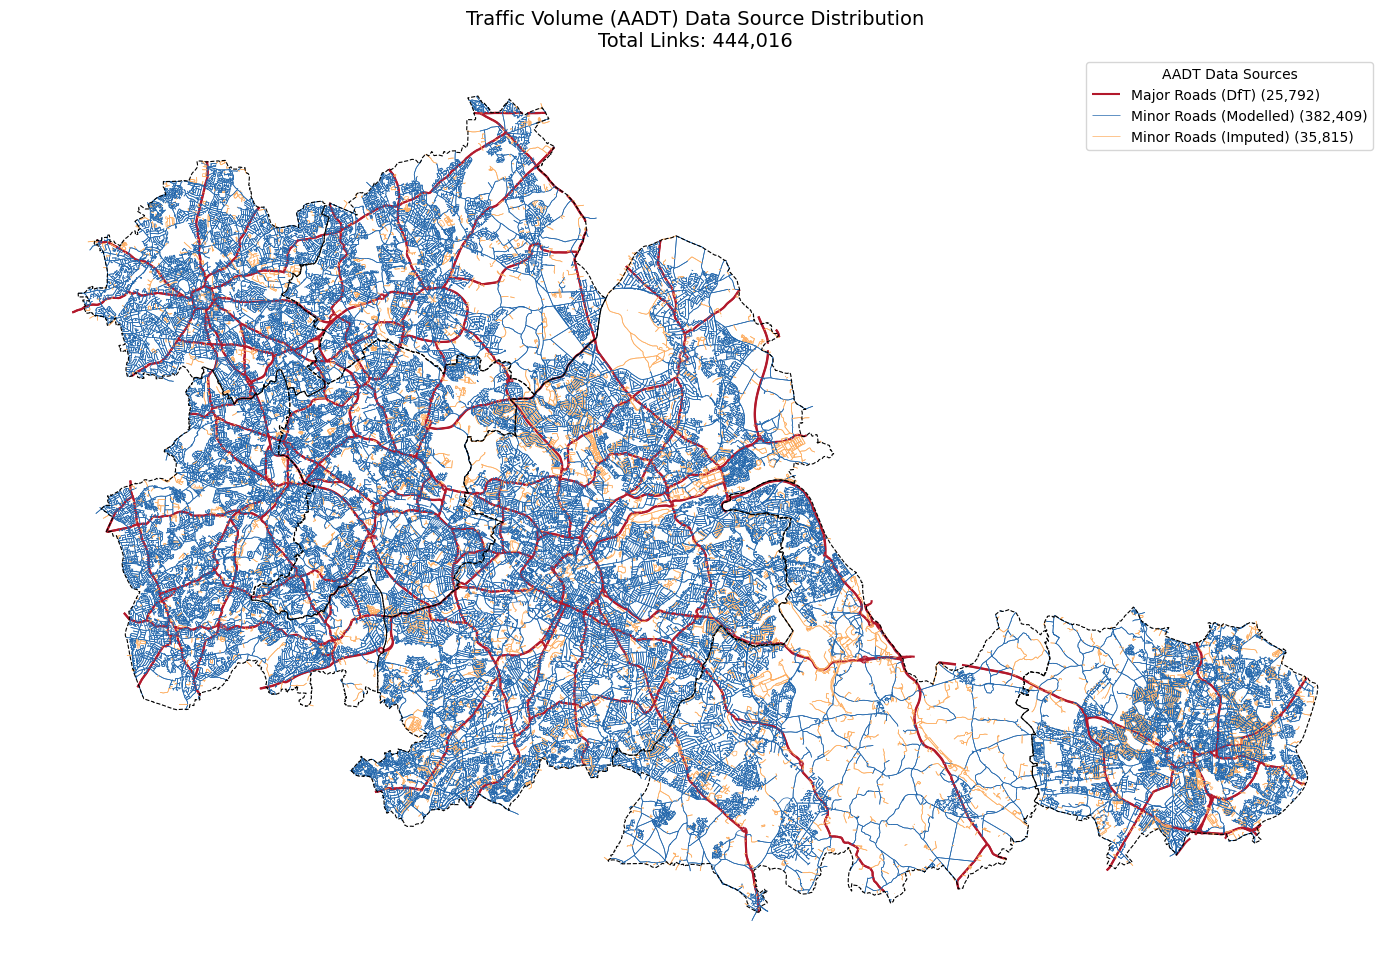

In [18]:
# =============================================================================
# 3.1 AADT Source Map
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 11))

# Re-classifying: Merge 'nearest_a_road' into a broader 'Imputed' category
b = network[network['aadt'].notna()].copy()
b['aadt_source_grouped'] = b['aadt_source'].replace({
    'class_median':   'Imputed',
    'nearest_a_road': 'Imputed'
})

# Define the new labeling and color scheme
source_map = {
    'dft':       {'label': 'Major Roads (DfT)', 'color': '#b2182b'},
    'predicted': {'label': 'Minor Roads (Modelled)', 'color': '#2166ac'},
    'Imputed':   {'label': 'Minor Roads (Imputed)', 'color': '#fdae61'}
}

# Plot each group
for source, info in source_map.items():
    subset = b[b['aadt_source_grouped'] == source]
    if len(subset) > 0:
        lw = 1.5 if source == 'dft' else 0.5
        subset.plot(ax=ax, color=info['color'], linewidth=lw,
                    label=f'{info["label"]} ({subset.shape[0]:,})')

# Handle missing data
b_na = b[b['aadt'].isna()]
if len(b_na) > 0:
    b_na.plot(ax=ax, color='black', linewidth=1.0, label=f'Missing ({b_na.shape[0]:,})')

# Add context
study_area.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8, linestyle='--')

# Finalize legend and appearance
ax.legend(loc='upper right', fontsize=10, title='AADT Data Sources', frameon=True)
ax.set_title(f'Traffic Volume (AADT) Data Source Distribution\nTotal Links: {b.shape[0]:,}', fontsize=14)
ax.set_axis_off()

plt.tight_layout()
plt.show()

### 3.2 A Road AADT Validation

Comparison of assigned AADT values (lines) against DfT count point measurements (dots)
using a shared colour scale. Consistent colouring between lines and nearby dots indicates
correct assignment.

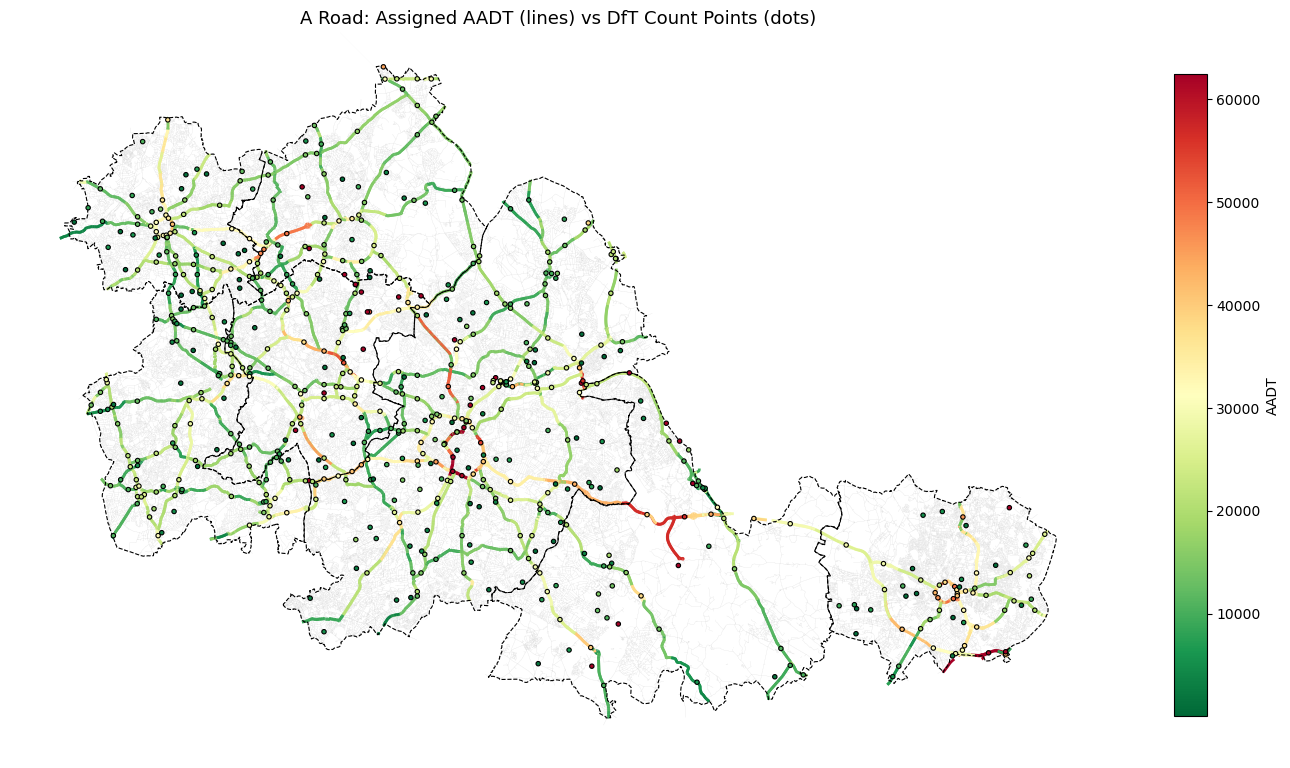

In [19]:
# =============================================================================
# 3.2 A Road AADT Validation — Assigned vs Count Points
# =============================================================================

import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(14, 11))

other = network[network['roadclassification'] != 'A Road']
other.plot(ax=ax, color='#e0e0e0', linewidth=0.1)

a_with = network[(network['roadclassification'] == 'A Road') & (network['aadt'].notna())]
vmin = min(a_with['aadt'].min(), dft_wm['dft_aadt'].min())
vmax = max(a_with['aadt'].quantile(0.95), dft_wm['dft_aadt'].quantile(0.95))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.RdYlGn_r

a_with.plot(ax=ax, column='aadt', cmap=cmap, norm=norm, linewidth=2.0)

dft_wm.plot(
    ax=ax, column='dft_aadt', cmap=cmap, norm=norm,
    markersize=10, marker='o', edgecolor='black', linewidth=0.8, zorder=5
)

study_area.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8, linestyle='--')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, shrink=0.6, label='AADT')

ax.set_title('A Road: Assigned AADT (lines) vs DfT Count Points (dots)', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()

### 3.3 AADT Distribution

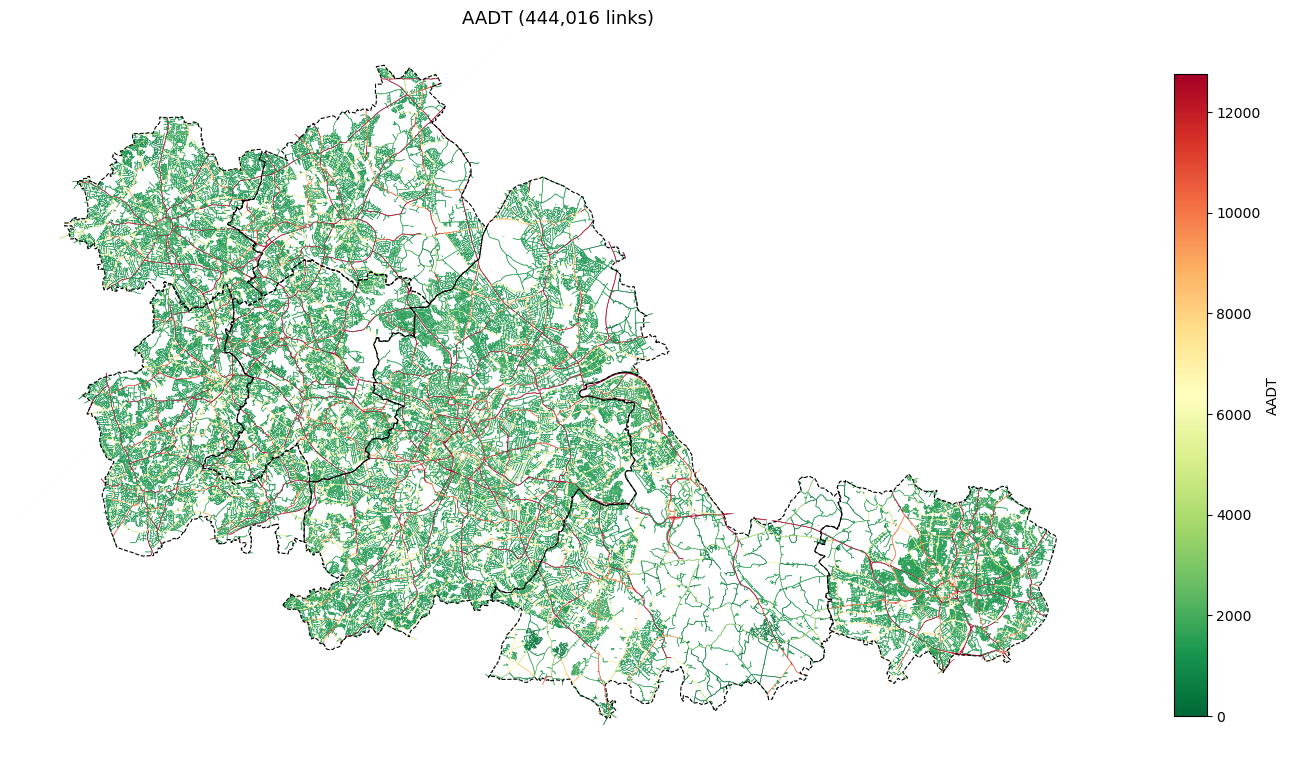

In [20]:
# =============================================================================
# 3.3 AADT Distribution
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 11))

b_with = network[network['aadt'].notna()]

b_with.plot(
    ax=ax, column='aadt', cmap='RdYlGn_r', linewidth=0.4,
    legend=True, legend_kwds={'label': 'AADT', 'shrink': 0.6},
    vmin=0, vmax=b_with['aadt'].quantile(0.95)
)

study_area.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8, linestyle='--')
ax.set_title(f'AADT ({b_with.shape[0]:,} links)', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()


## 4. Export

In [21]:
gpkg_path = OUTPUT_DIR / 'network_with_volume.gpkg'
network.to_file(gpkg_path, driver='GPKG')
print(f'Saved: {gpkg_path}')


Saved: ../Data/Cleaned/network_with_volume.gpkg
